# Explainability Plots

In [1]:
import warnings
import joblib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

from pathlib import Path
import shutil
from datetime import datetime
import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load / Reload Selection Utility Functions

In [2]:
from utils2 import explainability as exp

----

## Read Config File

In [3]:
config_path = Path(r'experiments')
config_filename =  "bin_exp_final.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - Explainability Analysis (development)',
  'classification_type': 'binary',
  'stage': 'explainability',
  'tag': 'final',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'param_space': {'iterations': {'min': 100, 'max': 500},
  'depth': {'min': 4, 'max': 10},
  'learning_rate': {'min': 0.01, 'max': 0.1},
  'l2_leaf_reg': {'min': 1, 'max': 9}},
 'hpo_results': {'file': 'binary\\hyperparameter_optimization\\CatBoost\\final\\optimization_results.json',
  'threshold': 0.6352084424142594},
 'optimization': {'scoring': 'roc_auc',
  'k_splits_outer': 3,
  'k_splits_inner': 3,
  'n_iter': 5}}

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\explainability\catboost\final


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/explainability/catboost/final/bin_exp_final.yml')

#### Verify Threshold Value

In [6]:
hpo_results_file = config.hpo_results.file
with open(config_path / hpo_results_file) as f:
    hpo_results = json.load(f)
assert np.isclose(hpo_results['threshold_mean'], config.hpo_results.threshold)

## Data Loading

In [7]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

## k-fold Optimization

In [8]:
split_results =  exp.get_ksplit_trained_models(X, y, config)


[[20  0]
 [ 4 40]]
youden:  0.9090909090909092
roc_auc:  0.9829545454545455

[[15  5]
 [ 1 42]]
youden:  0.7267441860465116
roc_auc:  0.986046511627907

[[18  2]
 [ 5 38]]
youden:  0.7837209302325583
roc_auc:  0.9441860465116279


In [9]:
df_ksm = pd.DataFrame([{k: result[k] for k in ["youden", "roc_auc"]} for result in split_results]).T
df_ksm['mean'] = df_ksm.mean(axis=1)
df_ksm['std'] = df_ksm.std(axis=1)
df_ksm

,0,1,2,mean,std
youden,0.909,0.727,0.784,0.807,0.076
roc_auc,0.983,0.986,0.944,0.971,0.019


### Save model results

In [10]:
rundate = datetime.now().strftime("%Y-%m-%d")
ksplit_trained_models = {
    "results": split_results,
    "summary": df_ksm,
    "rundate": rundate,
    "tag" : config.experiment.tag
}

In [11]:
joblib.dump(ksplit_trained_models, outputdir / f"{config.model.code}_ksplit_trained_models.joblib")

['experiments\\binary\\explainability\\catboost\\final\\catboost_ksplit_trained_models.joblib']

## Analysis Plots

In [12]:
ksplit_trained_models = joblib.load(outputdir / f"{config.model.code}_ksplit_trained_models.joblib")
ksplit_trained_models['summary']

,0,1,2,mean,std
youden,0.909,0.727,0.784,0.807,0.076
roc_auc,0.983,0.986,0.944,0.971,0.019


In [13]:
ksplit_trained_models['rundate'], ksplit_trained_models['tag']

('2026-03-15', 'final')

In [14]:
split_results = ksplit_trained_models['results']
split_results

[{'model': <catboost.core.CatBoostClassifier at 0x190990651c0>,
  'X_train':      SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
  0      1  64.0     1     7.0      1.0  15.00    0     0         0    0    0   
  1      0  59.0     1     1.0      0.0   5.60    1     0         0    0    0   
  5      0  20.0     1     2.0      1.0   7.80    0     0         0    0    0   
  6      0  69.0     0     0.0      0.0   8.00    1     0         1    0    0   
  7      0  60.0     0     2.0      0.0   5.80    1     0         0    0    0   
  8      1  62.0     0     0.0      1.0  14.36    0     0         0    0    0   
  9      0  44.0     1    17.0      0.0   7.01    0     0         0    0    0   
  10     0  70.0     0    10.0      0.0   6.40    1     0         0    1    0   
  11     1  61.0     1     4.0      0.0   8.30    0     0         1    1    0   
  12     1  57.0     1     7.0      1.0  13.00    0     0         1    0    0   
  14     0  78.0     1     5.0    

### Feature Importance

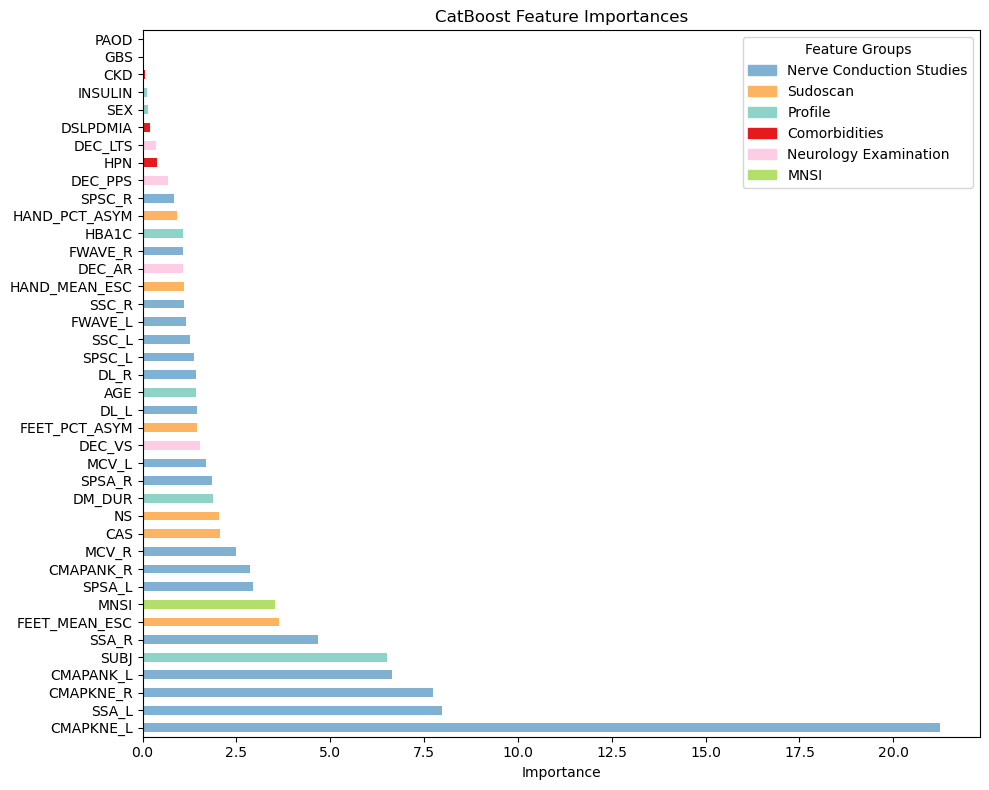

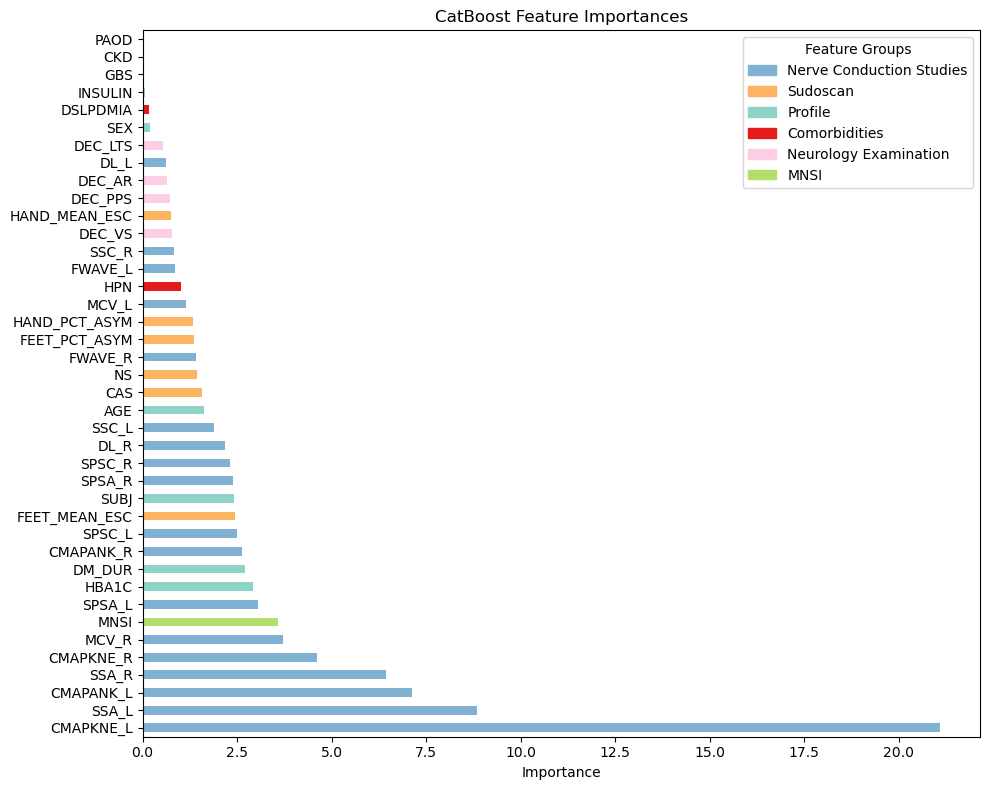

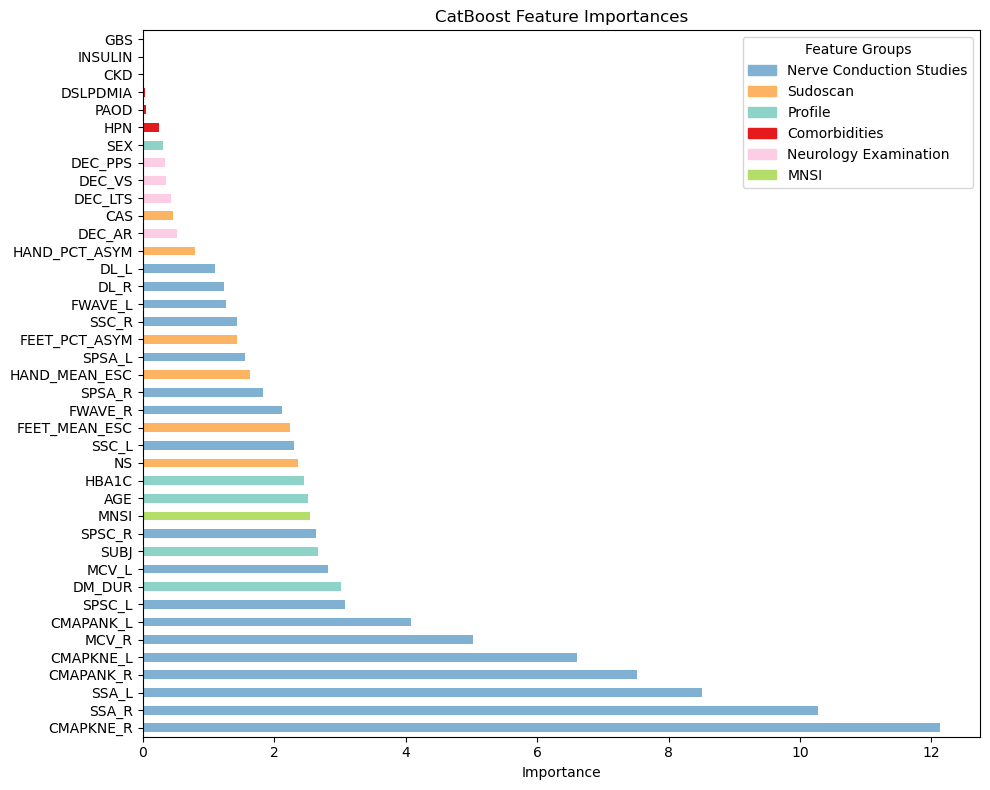

In [15]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    feature_names = X.columns
    exp.plot_importances(D, model, s, feature_names, config, 
                        minimum=None, limit=None, 
                        savedir=outputdir)    

#### ROC Curve

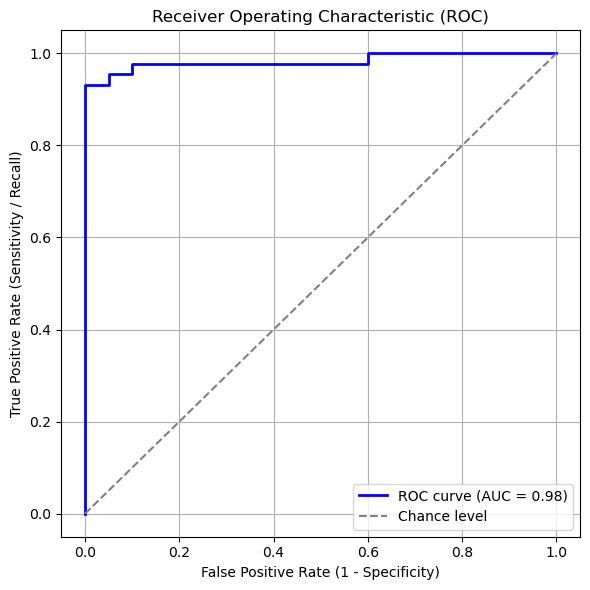

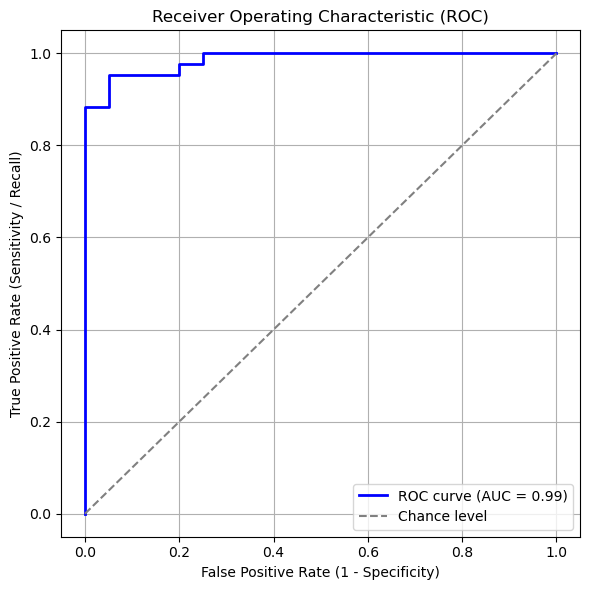

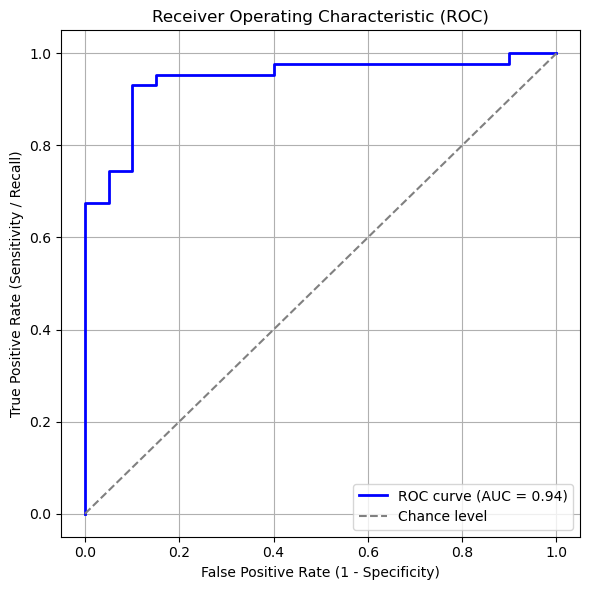

In [16]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    X_test = split_results[s]['X_test']
    y_test = split_results[s]['y_test']
    y_proba = model.predict_proba(X_test)[:,1]
    exp.plot_roc_auc(y_test, y_proba, s, config, outputdir);    


### DCA

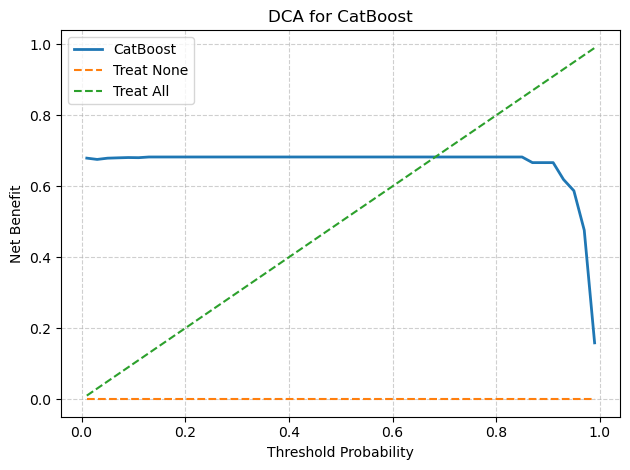

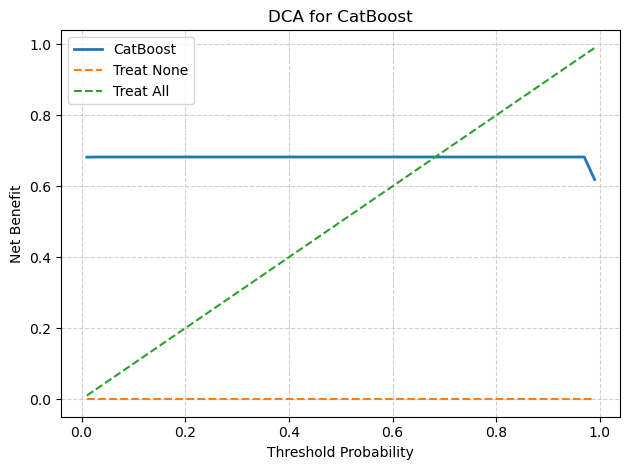

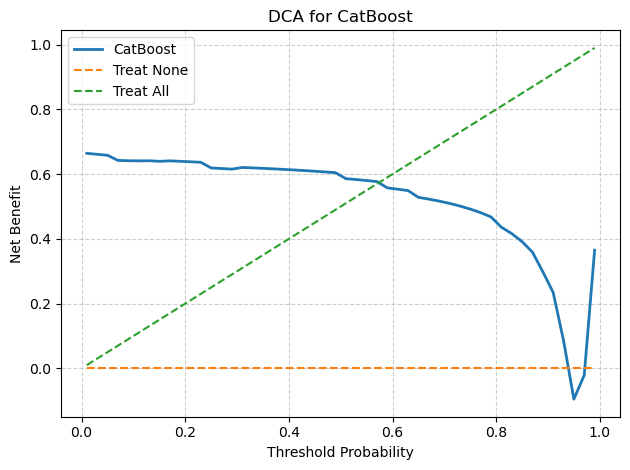

In [17]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    thresholds, nb = exp.plot_decision_curve_analysis(model, s, X_test, y_test, config, savedir=outputdir)

## SHAP Analysis

PermutationExplainer explainer: 64it [00:12,  3.12it/s]                        


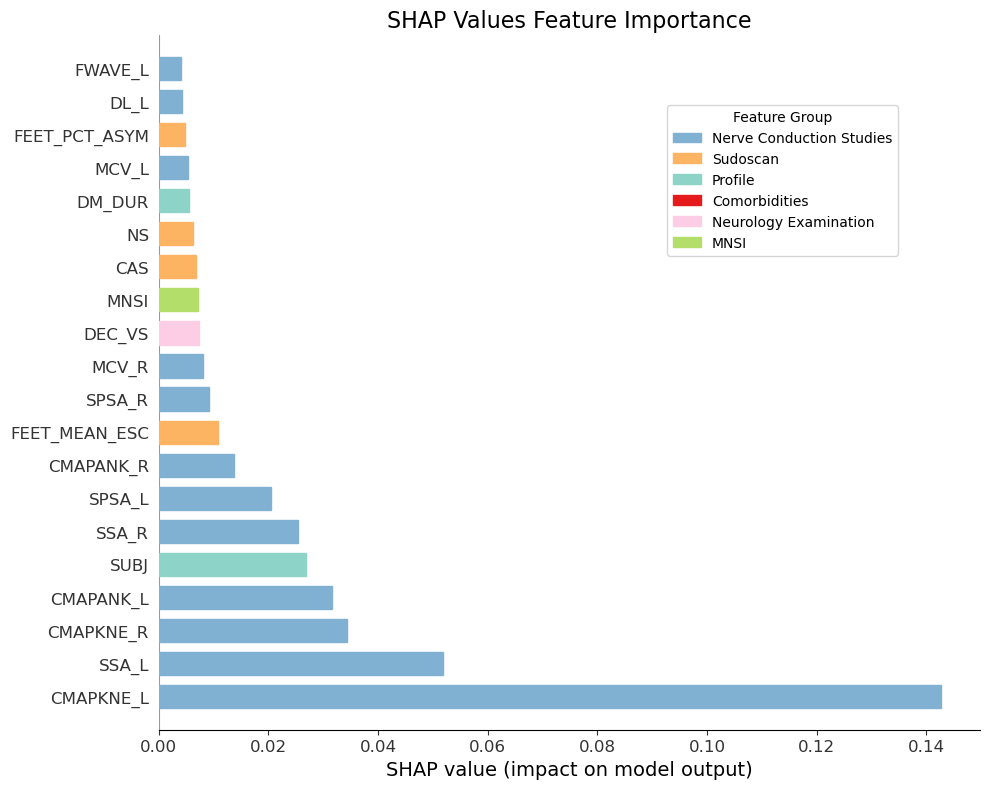

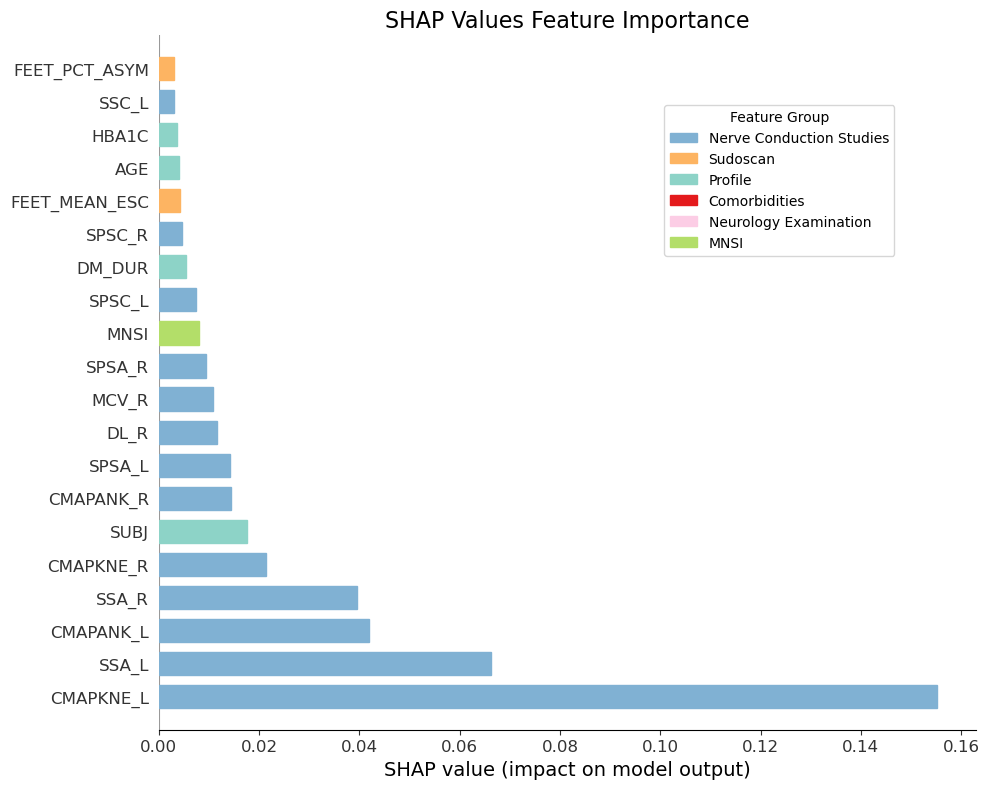

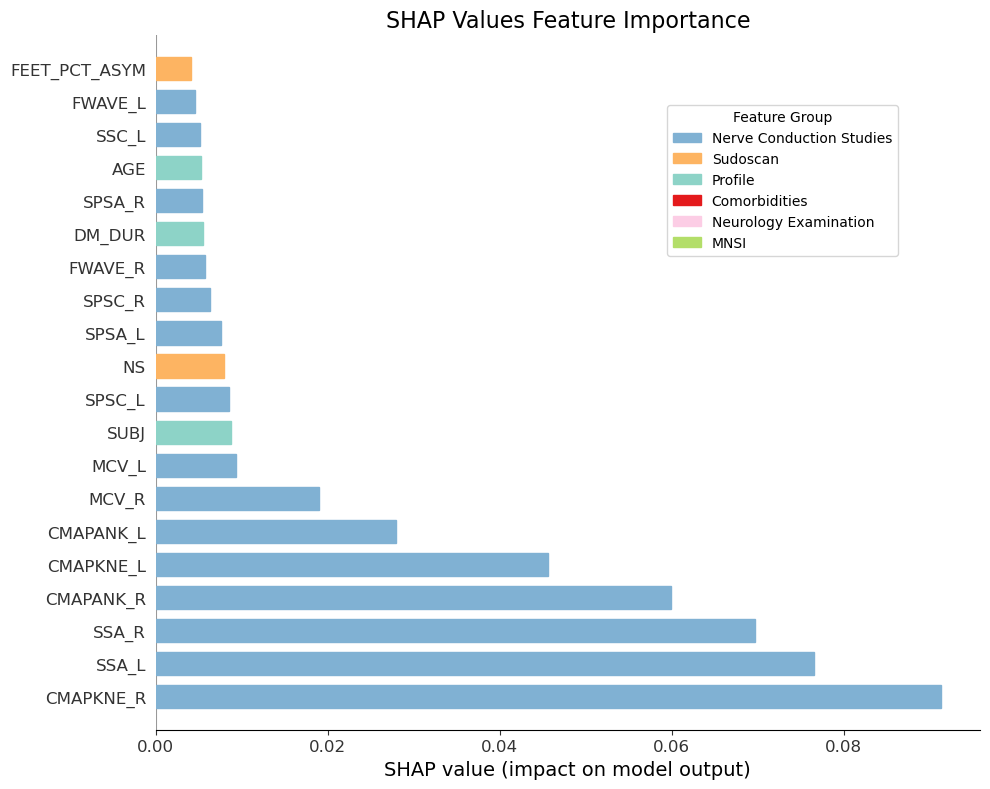

In [18]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    exp.plot_shap(D, model, s, config, X_test, savedir=outputdir)